# Flight Final Descent Anomaly Detection and Classification

Contributors: Elan Wilkinson, Melissa Short, Nicholas Short

## Setup Dependencies

In [ ]:
!pip install --disable-pip-version-check -q pip --upgrade > /dev/null
!pip install --disable-pip-version-check -q wrapt --upgrade > /dev/null

### AWS CLI and AWS Python SDK (boto3)

In [ ]:
!pip install --disable-pip-version-check -q awscli boto3

### SageMaker

In [ ]:
!pip install --disable-pip-version-check -q sagemaker
!pip install --disable-pip-version-check -q smdebug
!pip install --disable-pip-version-check -q sagemaker-experiments

### PyAthena

In [ ]:
!pip install --disable-pip-version-check -q PyAthena

### AWS Data Wrangler

In [ ]:
!pip install --disable-pip-version-check -q awswrangler

### Zip

In [ ]:
!conda install -y zip

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

# All requested packages already installed.



### Matplotlib

In [ ]:
!pip install --disable-pip-version-check -q matplotlib

### Seaborn

In [ ]:
!pip install --disable-pip-version-check -q seaborn

## Import Necessary Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Data lake Setup

In [ ]:
import boto3
import sagemaker

session = boto3.session.Session()
region = session.region_name
sagemaker_session = sagemaker.Session()
bucket = 'flightfinalapproachanomalydetection'#'sagemaker-us-east-1-817854913925' #sagemaker_session.default_bucket()

s3 = boto3.Session().client(service_name="s3", region_name=region)

print("Bucket name: {}".format(bucket))

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Bucket name: flightfinalapproachanomalydetection


### Verify Bucket Creation

In [ ]:
from botocore.client import ClientError

response = None
try:
    response = s3.head_bucket(Bucket=bucket)
    print(response)
    setup_s3_bucket_passed = True
except ClientError as e:
    print("[ERROR] Cannot find bucket {} in {} due to {}.".format(bucket, response, e))

{'ResponseMetadata': {'RequestId': 'H59G1FBRW43JAHMB', 'HostId': 'GBjj1QDvwW8EebNyx8DvHMMDvhC+JE/L/iLk5lO2biFeuNuKkwa7FZRksPxFPmBYESCc8fu2sXqUtGc51ojRf7yu3VmSckucj8uwl+Dnf9w=', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amz-id-2': 'GBjj1QDvwW8EebNyx8DvHMMDvhC+JE/L/iLk5lO2biFeuNuKkwa7FZRksPxFPmBYESCc8fu2sXqUtGc51ojRf7yu3VmSckucj8uwl+Dnf9w=', 'x-amz-request-id': 'H59G1FBRW43JAHMB', 'date': 'Fri, 31 Jan 2025 02:08:41 GMT', 'x-amz-bucket-region': 'us-east-1', 'x-amz-access-point-alias': 'false', 'content-type': 'application/xml', 'transfer-encoding': 'chunked', 'server': 'AmazonS3'}, 'RetryAttempts': 0}, 'BucketRegion': 'us-east-1', 'AccessPointAlias': False}


In [ ]:
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client(service_name="sagemaker", region_name=region)

In [ ]:
from IPython.core.display import display, HTML

display(
    HTML(
        '<b>Review <a target="blank" href="https://s3.console.aws.amazon.com/s3/buckets/flightfinalapproachanomalydetection/?region={}&tab=overview">S3 Bucket</a></b>'.format(
            region, account_id, region
        )
    )
)

/tmp/ipykernel_1381/88463448.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


## Create Athena Database Scheme
### Import PyAthena

In [ ]:
from pyathena import connect

In [ ]:
table_name_csv = "flight_csv_data"
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)

### Create Athena Database

In [ ]:
database_name = "flightdata_db"

In [ ]:
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)

In [ ]:
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

In [ ]:
statement = "CREATE DATABASE IF NOT EXISTS {}".format(database_name)
print(statement)

CREATE DATABASE IF NOT EXISTS flightdata_db


In [ ]:
cursor = conn.cursor()
cursor.execute(statement)
print("Database created successfully")


Database created successfully


In [ ]:
import pandas as pd

statement = "SHOW DATABASES"

df_show = pd.read_sql(statement, conn)
df_show.head(5)

/tmp/ipykernel_1381/2310636415.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_show = pd.read_sql(statement, conn)


,database_name
0,assignment2_aws
1,default
2,dsoaws
3,flightdata_db
4,sagemaker_featurestore


## Register CSV with Athena

In [ ]:
drop_statement = "DROP TABLE flightdata_db.flight_csv_data"
cursor = conn.cursor()
cursor.execute(drop_statement)
print("Table dropped successfully.")

Table dropped successfully.


In [ ]:
statement = """CREATE EXTERNAL TABLE IF NOT EXISTS flightdata_db.flight_csv_data (
        sample_id int,
        timestep int,
        aileron_pos_lh_deg float,
        aileron_pos_rh_deg float,
        corrected_angle_of_attack_deg float,
        baro_correct_alt_lsp_ft float,
        computed_airspeed_lsp_knots float,
        selected_course_deg float,
        drift_angle_deg float,
        elevator_pos_left_deg float,
        te_flap_pos_disc float,
        glideslope_dev_perc float,
        selected_heading_deg float,
        localizer_dev_perc float,
        core_speed_avg_perc float,
        total_pressure_lsp_millibar float,
        pitch_angle_lsp_deg float,
        roll_angle_lsp_deg float,
        rudder_pos_deg float,
        true_heading_lsp_deg float,
        vertical_accel_g float,
        wind_speed_knots float,
        label int
)
STORED AS TEXTFILE
LOCATION 's3://flightfinalapproachanomalydetection/csv/'
TBLPROPERTIES (
    'skip.header.line.count'='1',
    'field.delim'=',',
    'compressionType'='none'
)"""

In [ ]:
cursor = conn.cursor()
cursor.execute(statement)

In [ ]:
import pandas as pd
pd.read_sql(statement, conn)

/tmp/ipykernel_14886/1322682284.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(statement, conn)


""


In [ ]:
statement = "SHOW TABLES IN {}".format(database_name)
cursor = conn.cursor()
cursor.execute(statement)

In [ ]:
if table_name_csv in df_show.values:
    ingest_create_athena_table_csv_passed = True
else:
    ingest_create_athena_table_csv_passed = False
print(ingest_create_athena_table_csv_passed)

False


In [ ]:
print(database_name)
print(table_name_csv)

flightdata_db
flight_csv_data


In [ ]:
statement = """SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM {}.{}
    LIMIT 10""".format(
    database_name, table_name_csv
)

print(statement)

df = pd.read_sql(statement, conn)
df.head(5)

SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM flightdata_db.flight_csv_data
    LIMIT 10


/tmp/ipykernel_188/1784874562.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(statement, conn)


,sample_id,aileron_pos_lh_deg,timestep,label
0,0,81.261190,0,0
1,0,79.604095,1,0
2,0,81.302110,2,0
3,0,82.345470,3,0
4,0,81.874930,4,0


In [ ]:
statement = """SELECT label, COUNT(*) AS count
    FROM {}.{}
    GROUP BY label
    ORDER BY label""".format(
    database_name, table_name_csv
)


df = pd.read_sql(statement, conn)
df.head(10)

/tmp/ipykernel_188/624500045.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(statement, conn)


,label,count
0,0,14346080
1,1,1122080
2,2,353120
3,3,152640


The classes are significantly imbalanced, with 14 million nominal examples, 1 million speed high examples, 350,000 path high examples and 152,000 flaps late setting examples. It should be noted that this is time series data, so the number of individual flight recordings is a fraction of this.

### Check for Duplicates

## Feature Store

In [ ]:
from sagemaker.feature_store.feature_group import FeatureGroup
from time import gmtime, strftime, sleep
from sagemaker.session import Session

boto_session = boto3.Session(region_name=region)

sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
featurestore_runtime = boto_session.client(
    service_name="sagemaker-featurestore-runtime", region_name=region
)

record_identifer_feature_name = 'record_identifier'
event_time_feature_name = 'time_step'

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)

flight_feature_group_name = "flightfeature-group-" + strftime("%d-%H-%M-%S", gmtime())
flight_feature_group = FeatureGroup(name=flight_feature_group_name, sagemaker_session=feature_store_session
                                     )

In [ ]:
df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,record_identifier
0,0,0.0,81.261190,82.652336,-8.111792,1969.6174,155.57140,-2.109358,-0.692778,-4.952854,...,70.74118,985.42550,-3.662262,0.785912,-0.390141,-1.081870,0.972379,12.625183,0.0,0_0
1,0,1.0,79.604095,81.015700,-7.644611,1955.6995,154.51205,-2.109358,-0.867216,-5.198349,...,70.71775,985.52030,-3.665276,0.046774,-0.756234,-0.704820,0.770077,11.893839,0.0,0_1
2,0,2.0,81.302110,80.770200,-7.552573,1940.0267,153.32867,-2.109358,-1.424093,-4.830105,...,70.70276,985.41650,-3.940319,0.804820,-1.325632,-0.240446,0.543937,12.559112,0.0,0_2
3,0,3.0,82.345470,83.900276,-8.395265,1924.5493,150.88818,-2.109358,-1.141912,-4.625526,...,70.74159,984.81710,-4.275129,1.077102,-0.326884,-0.191627,1.062817,10.542998,0.0,0_3
4,0,4.0,81.874930,82.754620,-7.854284,1905.3670,150.69461,-2.109358,-0.724660,-4.400490,...,70.57045,985.23065,-4.241483,1.654806,0.129545,-0.528425,0.867628,9.713539,0.0,0_4


In [ ]:
flight_feature_group.load_feature_definitions(data_frame=df)

[FeatureDefinition(feature_name='sample_id', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='time_step', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='aileron_pos_lh_deg', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='aileron_pos_rh_deg', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='corrected_angle_of_attack_deg', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='baro_correct_alt_lsp_ft', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='computed_airspeed_lsp_knots', feature_type=<FeatureTypeEnum.FRACTIONAL: 'Fractional'>, collection_type=None),
 FeatureDefinition(feature_name='selected_course_deg', feat

### Creation of FeatureGroups in SageMaker FeatureStore

In [ ]:
import time

def wait_for_feature_group_creation_complete(feature_group):
    status = feature_group.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("Waiting for Feature Group Creation")
        time.sleep(5)
        status = feature_group.describe().get("FeatureGroupStatus")
    if status != "Created":
        raise RuntimeError(f"Failed to create feature group {feature_group.name}")
    print(f"FeatureGroup {feature_group.name} successfully created.")


flight_feature_group.create(
    s3_uri=f"s3://{bucket}/feature_group",
    record_identifier_name=record_identifer_feature_name,
    event_time_feature_name=event_time_feature_name,
    role_arn=role,
    enable_online_store=True,
)


wait_for_feature_group_creation_complete(feature_group=flight_feature_group)

Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
FeatureGroup flightfeature-group-31-02-10-56 successfully created.


In [ ]:
flight_feature_group.describe()

{'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:817854913925:feature-group/flightfeature-group-31-02-10-56',
 'FeatureGroupName': 'flightfeature-group-31-02-10-56',
 'RecordIdentifierFeatureName': 'record_identifier',
 'EventTimeFeatureName': 'time_step',
 'FeatureDefinitions': [{'FeatureName': 'sample_id',
   'FeatureType': 'Integral'},
  {'FeatureName': 'time_step', 'FeatureType': 'Fractional'},
  {'FeatureName': 'aileron_pos_lh_deg', 'FeatureType': 'Fractional'},
  {'FeatureName': 'aileron_pos_rh_deg', 'FeatureType': 'Fractional'},
  {'FeatureName': 'corrected_angle_of_attack_deg',
   'FeatureType': 'Fractional'},
  {'FeatureName': 'baro_correct_alt_lsp_ft', 'FeatureType': 'Fractional'},
  {'FeatureName': 'computed_airspeed_lsp_knots', 'FeatureType': 'Fractional'},
  {'FeatureName': 'selected_course_deg', 'FeatureType': 'Fractional'},
  {'FeatureName': 'drift_angle_deg', 'FeatureType': 'Fractional'},
  {'FeatureName': 'elevator_pos_left_deg', 'FeatureType': 'Fractional'},
  {'Featu

In [ ]:
sagemaker_client.list_feature_groups()

{'FeatureGroupSummaries': [{'FeatureGroupName': 'neighborhood-feature-group-26-05-02-41',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:817854913925:feature-group/neighborhood-feature-group-26-05-02-41',
   'CreationTime': datetime.datetime(2025, 1, 26, 5, 2, 52, 140000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created',
   'OfflineStoreStatus': {'Status': 'Active'}},
  {'FeatureGroupName': 'neighborhood-feature-group-26-04-11-14',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:817854913925:feature-group/neighborhood-feature-group-26-04-11-14',
   'CreationTime': datetime.datetime(2025, 1, 26, 4, 11, 18, 797000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created'},
  {'FeatureGroupName': 'flightfeature-group-31-02-10-56',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:817854913925:feature-group/flightfeature-group-31-02-10-56',
   'CreationTime': datetime.datetime(2025, 1, 31, 2, 10, 57, 185000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created'},
  {'FeatureGroup

In [ ]:
flight_feature_group.ingest(data_frame=df, max_workers=5, wait=True)

In [ ]:
feats_to_quer = ['0_0','0_150']

for val in feats_to_quer:
    record_identifier_value = val

    response = featurestore_runtime.get_record(
        FeatureGroupName=neighborhood_feature_group_name,
        RecordIdentifierValueAsString=record_identifier_value,
    )

    if 'Record' in response and response['Record']:
        print("Record",val,"found:")
        for feature in response['Record']:
            print(f"{feature['FeatureName']}: {feature['ValueAsString']}")
        print("\n\n")
    else:
        print("Record",val,"not found.")
        print("\n\n")


## Training

### Class Balancing

In [7]:
import random
num_unique = (int)(len((df[df['label'] == 3]))/160)
rand_zeroes = df[df['label'] == 0]['sample_id'].unique()
print(num_unique)
unique_zeros = random.choices(rand_zeroes, k=num_unique)
print(len(unique_zeros))
rand_ones = df[df['label'] == 1]['sample_id'].unique()
unique_ones = random.choices(rand_ones, k=num_unique)
rand_twos = df[df['label'] == 2]['sample_id'].unique()
unique_twos = random.choices(rand_twos, k=num_unique)
sampleids_to_keep = df[df['label'] == 3]['sample_id'].unique().tolist()
print(len(sampleids_to_keep))
sampleids_to_keep.extend(unique_ones)
print(len(sampleids_to_keep))
sampleids_to_keep.extend(unique_twos)
print(len(sampleids_to_keep))
sampleids_to_keep.extend(unique_zeros)
print(len(sampleids_to_keep))

training_df = df[df['sample_id'].isin(sampleids_to_keep)]

382
382
382
764
1146
1528


#### Append Categorically Encoded Arrival Airport

In [8]:
training_df = training_df.merge(arrival_and_samp, on='sample_id', how='left')

### Data Scaling

In [9]:
float_columns = [col for col in training_df.columns if col not in ['sample_id', 'time_step', 'label'] and training_df[col].dtype == 'float64']


from sklearn.preprocessing import MinMaxScaler

df_scaled = training_df.copy()
scalers = []
for col in float_columns:
  new_scaler = MinMaxScaler()
  df_scaled[col] = new_scaler.fit_transform(df_scaled[[col]])
  scalers.append(new_scaler)

In [ ]:
df_scaled.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,22,0,0.476770,0.522024,0.397348,0.208995,0.586561,0.276523,0.600624,0.461252,...,0.636064,0.901466,0.668200,0.546864,0.490226,0.333373,0.884693,0.207371,0.0,0.076087
1,22,1,0.485217,0.527792,0.386327,0.209063,0.582375,0.276523,0.595762,0.459762,...,0.661452,0.900796,0.663884,0.549276,0.488864,0.334078,0.878830,0.204424,0.0,0.076087
2,22,2,0.484472,0.519927,0.380792,0.209112,0.577332,0.276523,0.596786,0.462991,...,0.668880,0.900329,0.658712,0.539548,0.488949,0.334263,0.876248,0.191354,0.0,0.076087
3,22,3,0.481242,0.530152,0.396675,0.209107,0.576332,0.276523,0.590385,0.463239,...,0.690644,0.900260,0.667756,0.529912,0.487811,0.334857,0.880116,0.187972,0.0,0.076087
4,22,4,0.496646,0.536969,0.394948,0.209014,0.574968,0.276523,0.593907,0.461003,...,0.661454,0.900140,0.666822,0.524619,0.487642,0.334542,0.880369,0.187752,0.0,0.076087


In [10]:
train_x = df_scaled.copy()
train_x = train_x.drop(columns=['label','sample_id'])
train_y = df_scaled['label']

### Import and Prepare Validation Data

In [11]:
valid_df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/valid_flight_data.csv")
valid_df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg',
'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

#

In [12]:
valid_ids = valid_df['sample_id'].unique()
print(valid_ids)
flight_metadata_valid = flight_metadata_df[flight_metadata_df['data_instance'].isin(valid_ids)]
flight_metadata_valid.head()
arrival_and_samp = flight_metadata_valid.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp
valid_df = valid_df.merge(arrival_and_samp, on='sample_id', how='left')
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(dict(enumerate(arrival_airport_mapping)))
valid_df.tail()



[   15    20    21 ... 99806 99809 99810]


,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport,arrival_airport_catenc
1629275,99810,155,83.73661,69.49784,1.817228,616.34467,125.377450,-145.0185,-0.701310,-1.822781,...,1004.52594,3.309562,1.056722,-0.471746,-151.14806,0.991589,1.355669,3.0,KDTW,NaN
1629276,99810,156,82.55005,74.89876,1.139800,614.71620,124.622140,-145.0185,-1.029845,-1.679573,...,1004.09440,3.003177,1.689748,-0.586573,-150.18675,1.009410,2.146087,3.0,KDTW,NaN
1629277,99810,157,79.89050,77.19005,1.652527,613.72650,123.039150,-145.0185,-1.113408,0.018440,...,1003.51263,3.108795,0.979927,-0.487490,-150.80489,0.973769,2.340231,3.0,KDTW,NaN
1629278,99810,158,78.21295,73.48715,1.715791,616.63040,121.915794,-145.0185,-1.802660,5.664848,...,1002.90576,2.889801,0.005120,-0.576744,-149.50856,1.035906,3.913119,3.0,KDTW,NaN
1629279,99810,159,73.46670,70.37753,0.894369,614.58470,119.480550,-145.0185,-1.632066,3.046223,...,1001.97240,2.361194,-0.899853,-0.491064,-150.44374,0.995308,3.952124,3.0,KDTW,NaN


In [13]:
arrival_airport_mapping_dict = {airport: idx for idx, airport in enumerate(arrival_airport_mapping)}
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(arrival_airport_mapping_dict)
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport_catenc'].astype(float)
valid_df.drop(columns=['arrival_airport'], inplace=True)
valid_df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,15,0,80.606540,81.54761,-5.420757,2468.7761,180.01007,34.98022,3.319528,-3.500336,...,61.523205,978.03235,-1.985861,-1.344085,-2.817326,24.699790,1.015660,14.561880,0.0,5.0
1,15,1,79.849594,80.42242,-5.116660,2453.4820,178.55055,34.98022,3.403981,-3.561710,...,61.480885,977.95966,-1.719461,-1.292599,1.381010,24.573366,1.040051,14.044608,0.0,5.0
2,15,2,81.506690,82.01814,-4.978041,2441.3076,179.56377,34.98022,3.030978,-3.459419,...,61.483383,978.70500,-1.735226,0.008662,-3.048076,24.782553,1.032340,14.027080,0.0,5.0
3,15,3,81.813560,82.79555,-5.357613,2426.1600,177.57582,34.98022,3.490517,-3.664001,...,61.506645,978.21350,-1.802503,1.149909,1.843847,24.539455,1.000205,13.811078,0.0,5.0
4,15,4,82.652336,83.10242,-6.084550,2411.2341,179.69500,34.98022,3.546878,-3.664001,...,61.506870,980.06050,-2.078131,0.974984,-2.606024,24.573948,0.967859,15.460607,0.0,5.0


In [14]:
valid_scaled = valid_df.copy()
for i in range (0,len(float_columns)):
  valid_scaled[float_columns[i]] = scalers[i].transform(valid_scaled[[float_columns[i]]])

In [15]:
valid_x = valid_scaled.copy()
valid_x = valid_x.drop(columns=['label','sample_id'])
valid_y = valid_scaled['label']

### Modeling

In [17]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from tensorflow.keras.utils import to_categorical

import numpy as np

In [18]:
!pip install --upgrade tensorflow

In [19]:
num_samples = len(train_x) // 160
num_features = train_x.shape[1]

# Reshape the data
train_data = train_x.values.reshape((num_samples, 160, num_features))
train_y = df_scaled['label']
train_y = np.array(train_y)
train_data_y = []
for i in range(0,len(train_y),160):
  train_data_y.append(train_y[i])
train_y = train_y.astype(int)
train_y = np.array(train_data_y)
print(train_y)


[0. 0. 0. ... 3. 3. 3.]


In [20]:
train_y = to_categorical(train_y)

In [25]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, input_shape=(160, num_features)))
model.add(Dense(4, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
hist = model.fit(train_data, train_y, epochs=175, batch_size=64)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.2454 - loss: 1.4083
Epoch 2/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.2719 - loss: 1.3813
Epoch 3/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2836 - loss: 1.3794
Epoch 4/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.2477 - loss: 1.3831
Epoch 5/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3019 - loss: 1.3797
Epoch 6/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.2789 - loss: 1.3768
Epoch 7/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.2856 - loss: 1.3757
Epoch 8/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3113 - loss: 1.3753
Epoch 9/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3451 - loss: 1.3436
Epoch 10/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3680 - loss: 1.3155
Epoch 11/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3422 - loss: 1.3624
Epoch 12/175
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms

Text(0.5, 1.0, 'model loss')

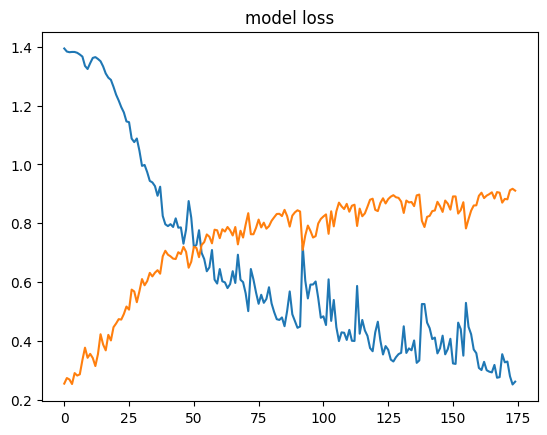

In [26]:
# plot hist
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.title('model loss')

In [27]:
num_samples = len(valid_x) // 160
num_features = valid_x.shape[1]

# Reshape the validation data similar to the training data
valid_data = valid_x.values.reshape((num_samples, 160, num_features))
valid_y = np.array(valid_y)
valid_data_y = []
for i in range(0,len(valid_y),160):
  valid_data_y.append(valid_y[i])

# generate predictions on valid data using the reshaped data
preds = model.predict(valid_data)  # Use valid_data instead of valid_x

# output classification report
import numpy as np
from sklearn.metrics import classification_report

preds = np.argmax(preds, axis=1)
print(classification_report(valid_data_y, preds)) # Use valid_data_y instead of valid_y

319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89      9146
         1.0       0.34      0.81      0.48       715
         2.0       0.21      0.70      0.32       225
         3.0       0.61      0.97      0.75        97

    accuracy                           0.81     10183
   macro avg       0.54      0.82      0.61     10183
weighted avg       0.92      0.81      0.85     10183



### Model and Training Job Creation

In [ ]:
%%time
from time import gmtime, strftime
import sagemaker
from sagemaker.tensorflow import TensorFlow

job_name = "lstm-" + strftime("%Y-%m-%d-%H-%M-%S", gmtime())
output_location = "s3://{}/{}/output/{}".format(bucket, prefix, job_name)

# Create a TensorFlow estimator
sm_estimator = TensorFlow(
    image,
    role,
    instance_count=1,
    instance_type="ml.m4.xlarge",
    input_mode="File",
    output_path=output_location,
    hyperparameters={
        "epochs": 50,
        "batch_size": 64,
        "learning_rate": 0.001,
        "hidden_units": 128,
        "dropout": 0.2,
    },
    sagemaker_session=sess,
)

train_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
validation_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validation".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
data_channels = {"train": train_data, "validation": validation_data}

# Start training
sm_estimator.fit(inputs=data_channels, job_name=job_name, logs=True)

### Batch Transform

In [ ]:
%%time

sm_transformer = sm_estimator.transformer(1, "ml.m4.xlarge")

# start a transform job
input_location = "s3://{}/{}/batch/{}".format(
    bucket, prefix, label ## REPLACE WITH TRAINING CSV FROM LSTM MODEL OR LABELS
)  # use input data without ID column
sm_transformer.transform(input_location, content_type="text/csv", split_type="Line")
sm_transformer.wait()

In [ ]:
import re


def get_csv_output_from_s3(s3uri, batch_file): #REPLACE WITH TRAINING CSV FROM LSTM MODEL
    file_name = "{}.out".format(batch_file)
    match = re.match("s3://([^/]+)/(.*)", "{}/{}".format(s3uri, file_name))
    output_bucket, output_prefix = match.group(1), match.group(2)
    s3.download_file(output_bucket, output_prefix, file_name)
    return pd.read_csv(file_name, sep=",", header=None)

In [ ]:
output_df = get_csv_output_from_s3(sm_transformer.output_path, batch_file_noID) label ## REPLACE WITH TRAINING CSV FROM LSTM MODEL OR LABELS
output_df.head(8)

In [ ]:
# content_type / accept and split_type / assemble_with are required to use IO joining feature
sm_transformer.assemble_with = "Line"
sm_transformer.accept = "text/csv"

# start a transform job
input_location = "s3://{}/{}/batch/{}".format(
    bucket, prefix, batch_file label ## REPLACE WITH TRAINING CSV FROM LSTM MODEL
)  # use input data with ID column cause InputFilter will filter it out
sm_transformer.transform(
    input_location,
    split_type="Line",
    content_type="text/csv",
    input_filter="$[1:]",
    join_source="Input",
)
sm_transformer.wait()

In [ ]:
output_df = get_csv_output_from_s3(sm_transformer.output_path, batch_file)
output_df.head(8)

In [ ]:
# start another transform job
sm_transformer.transform(
    input_location,
    split_type="Line",
    content_type="text/csv",
    input_filter="$[1:]",
    join_source="Input",
    output_filter="$[0,-1]",
)
sm_transformer.wait()

In [ ]:
output_df = get_csv_output_from_s3(sm_transformer.output_path, batch_file)
output_df.head(8)

#### 3. Update the output filter to keep only ID and prediction results